# Initial model

We'll look at the structure of the initial model we begin with in lab 1

In [3]:
import mesa_reader as mr
model = mr.MesaData("1.1Msun_ONe.mod")

In [4]:
import matplotlib.pyplot as plt

In [6]:
model.bulk_names

['zone',
 'lnd',
 'lnT',
 'lnR',
 'L',
 'dq',
 'mlt_vc',
 'neut',
 'h1',
 'h2',
 'he3',
 'he4',
 'li7',
 'be7',
 'b8',
 'c12',
 'c13',
 'n13',
 'n14',
 'n15',
 'o16',
 'o17',
 'o18',
 'f19',
 'ne20',
 'ne21',
 'ne22',
 'na21',
 'na22',
 'na23',
 'mg24',
 'mg25',
 'mg26',
 'al25',
 'al26',
 'al27']

In [7]:
import numpy as np

In [8]:
rho = np.exp(model.lnd)
T = np.exp(model.lnT)
r = np.exp(model.lnR)

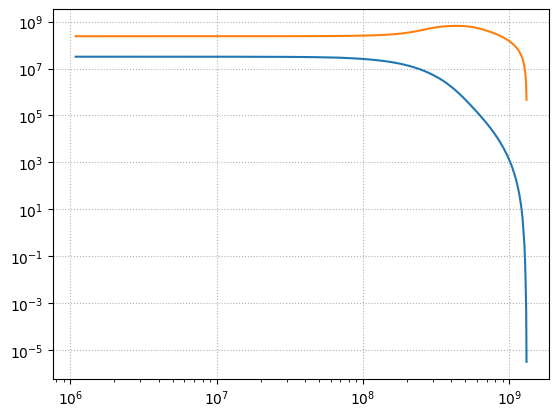

In [11]:
fig, ax = plt.subplots()
ax.loglog(r, rho)
ax.loglog(r, T)
ax.grid(ls=":")

## Using lab1 profiles

In [12]:
model1 = mr.MesaData("lab1/profile1.data")
model2 = mr.MesaData("lab1/profile2.data")

In [17]:
m1 = model1.mass
rho1 = 10.0**model1.logRho
T1 = 10.0**model1.logT

In [20]:
m2 = model2.mass
rho2 = 10.0**model2.logRho
T2 = 10.0**model2.logT

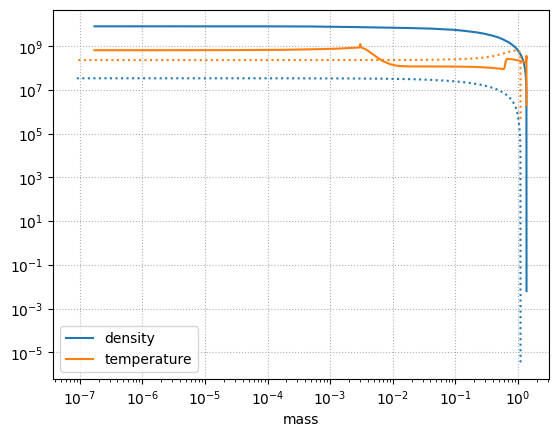

In [25]:
fig, ax = plt.subplots()
ax.loglog(m2, rho2, color="C0", label="density")
ax.loglog(m1, rho1, color="C0", ls=":")
ax.loglog(m2, T2, color="C1", label="temperature")
ax.loglog(m1, T1, color="C1", ls=":")
ax.legend()
ax.set_xlabel("mass")
ax.grid(ls=":")

## Fermi energy

We can compute the Fermi energy, but getting the degeneracy parameter, 
$\eta = \mathcal{E}_F/(kT) = (\mu - m_e c^2)/(kT)$

In [28]:
import pynucastro as pyna

In [29]:
eos = pyna.eos.ElectronEOS()

In [47]:
kB = pyna.constants.constants.k
erg2MeV = pyna.constants.constants.erg2MeV

In [37]:
from pynucastro import mesa_utils

We'll work with the late time model

In [38]:
mesa_zones = mesa_utils.get_all_data(model2)

In [45]:
E_fermi = np.zeros_like(rho2)
for i, v in mesa_zones.items():
    rho, T, comp = v
    es, ps = eos.pe_state(rho, T, comp, compute_derivs=False)
    eta = es.eta
    E_fermi[i] = eta * kB * T

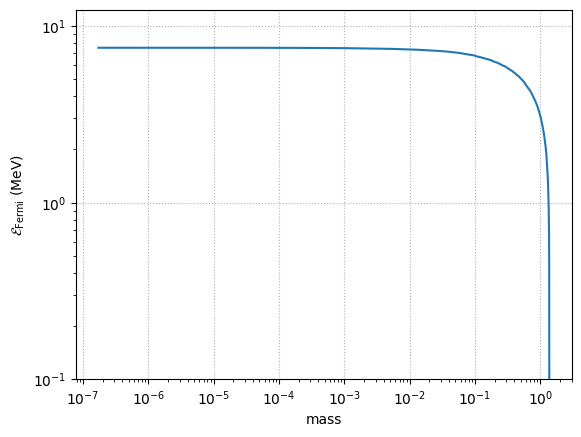

In [51]:
fig, ax = plt.subplots()
ax.loglog(m2, E_fermi * erg2MeV)
ax.set_xlabel("mass")
ax.set_ylabel(r"$\mathcal{E}_\mathrm{Fermi}$ (MeV)")
ax.set_ylim(1.e-1)
ax.grid(ls=":")